In [ ]:
#Setup and importz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
#Load preprocessed splits
X_train_resampled = pd.read_csv("Data/X_train_resampled.csv")
y_train_resampled = pd.read_csv("Data/y_train_resampled.csv").squeeze()
X_val_scaled = pd.read_csv("Data/X_val_scaled.csv")
y_val = pd.read_csv("Data/y_val.csv").squeeze()
X_test_scaled = pd.read_csv("Data/X_test_scaled.csv")
y_test = pd.read_csv("Data/y_test.csv").squeeze()
print("Loaded preprocessed splits.")
print(f"Train size: {X_train_resampled.shape[0]:,}")
print(f"Val size:   {X_val_scaled.shape[0]:,}")
print(f"Test size:  {X_test_scaled.shape[0]:,}")

Loaded preprocessed splits.
Train size: 288,488
Val size:   34,467
Test size:  34,468


In [ ]:
#Model tuning and training
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
}

mlp_base = MLPClassifier(
    max_iter=100,
    early_stopping=True,
    random_state=RANDOM_STATE
)

mlp_grid = GridSearchCV(
    mlp_base,
    mlp_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {mlp_grid.best_params_}")
print(f"Best CV AUC: {mlp_grid.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/arsshbajpai/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/arsshbajpai/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/arsshbajpai/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/arsshbajpai/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warning

Best params: {'activation': 'relu', 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01}
Best CV AUC: 0.8985


In [ ]:
#validation results
mlp_best = mlp_grid.best_estimator_

mlp_val_preds = mlp_best.predict(X_val_scaled)
mlp_val_probs = mlp_best.predict_proba(X_val_scaled)[:, 1]

print("=== MLP — Validation Set Results ===\n")
print(classification_report(y_val, mlp_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, mlp_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, mlp_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, mlp_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, mlp_val_preds):.4f}")

=== MLP — Validation Set Results ===

               precision    recall  f1-score   support

        No HD       0.95      0.80      0.87     30910
Heart Disease       0.26      0.61      0.37      3557

     accuracy                           0.78     34467
    macro avg       0.61      0.71      0.62     34467
 weighted avg       0.88      0.78      0.82     34467

AUC-ROC:   0.8005
F1:        0.3694
Precision: 0.2644
Recall:    0.6123


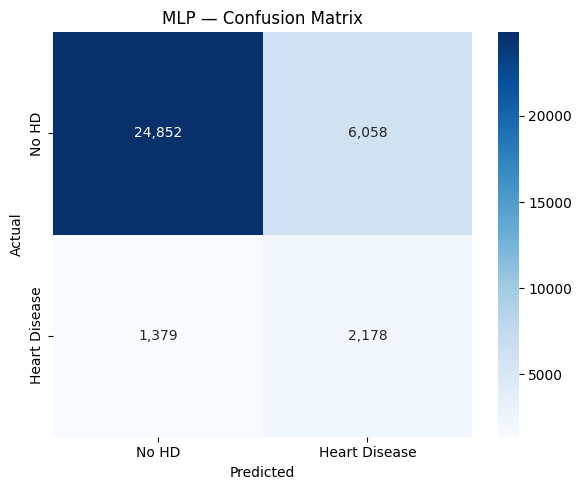

In [ ]:
#Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, mlp_val_preds)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('MLP — Confusion Matrix')
plt.tight_layout()
plt.show()

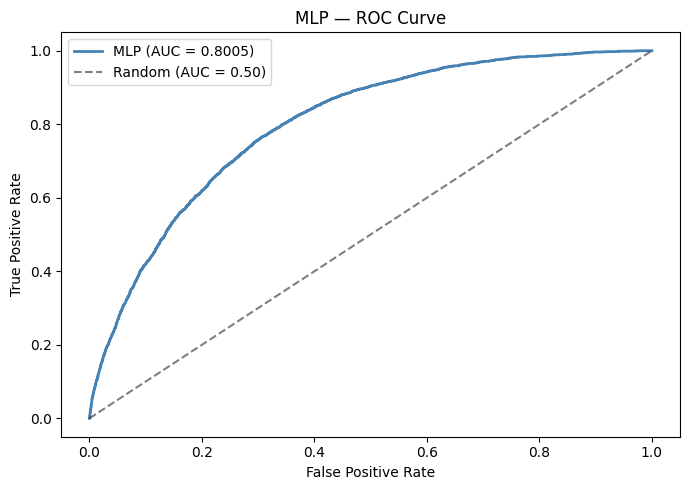

In [ ]:
#Roc curve
fig, ax = plt.subplots(figsize=(7, 5))
mlp_fpr, mlp_tpr, _ = roc_curve(y_val, mlp_val_probs)
mlp_auc = roc_auc_score(y_val, mlp_val_probs)
ax.plot(mlp_fpr, mlp_tpr, color='steelblue', lw=2, label=f'MLP (AUC = {mlp_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('MLP — ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()